## <u>Import Libraries</u>

In [3]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torchvision
from torch.utils.data import DataLoader, TensorDataset
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder  # loads any dataset from a folder of class-named subfolders
import torch.optim as optim
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

---
## <u>Device Setup — GPU via MPS</u>

Apple Silicon Macs don't have an NVIDIA GPU, so the usual `cuda` path doesn't apply -- PyTorch's Apple-specific backend is `mps` (Metal Performance Shaders) instead. Every model and every batch of data needs to be explicitly moved onto this `device` with `.to(device)` -- PyTorch requires the model and its input tensors to live on the *same* device, mixing CPU and MPS tensors in one operation throws an error immediately.

In [4]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(device)  # should print: mps

mps


---
## <u>Check Folder Structure</u>

`ImageFolder` needs class-named subfolders exactly one level in (e.g. `dataset_cat_dog/training_set/cats/`, `.../dogs/`). Worth confirming the real structure before pointing `ImageFolder` at it, since downloaded zips sometimes nest an extra folder layer.

In [5]:
import os
for root, dirs, files in os.walk("dataset_cat_dog"):
    print(root, dirs[:5], len(files))

dataset_cat_dog ['training_set', 'test_set'] 1
dataset_cat_dog/training_set ['dogs', 'cats'] 1
dataset_cat_dog/training_set/dogs [] 4006
dataset_cat_dog/training_set/cats ['.ipynb_checkpoints'] 4001
dataset_cat_dog/training_set/cats/.ipynb_checkpoints [] 1
dataset_cat_dog/test_set ['dogs', 'cats'] 0
dataset_cat_dog/test_set/dogs [] 1013
dataset_cat_dog/test_set/cats [] 1012


---
## <u>Image Transformations</u>

Binary classification problem (cat vs dog). Two differences from the CIFAR10 build:
- **`Resize((128,128))` is new and necessary here** -- CIFAR10 images were already a uniform 32x32, these are real photos of varying sizes. Every image has to be forced to the same size before it can go through `Conv2d`/`Linear` layers, which expect a fixed input shape. `Resize` runs on the raw image, *before* `ToTensor`.
- `ToTensor()` + `Normalize` work exactly as before -- convert to tensor and scale to `(0,1)`, then re-center to `(-1,1)` using the standard `0.5`/`0.5` per-channel convention.

In [6]:
transformations = transforms.Compose([
    transforms.Resize((128, 128)),  # force every image to the same size, regardless of its original dimensions
    transforms.ToTensor(),           # converts image to pytorch tensor and scales to (0,1)
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))  # mean/std per RGB channel, maps (0,1) -> (-1,1)
])

---
## <u>Load Training and Testing Sets</u>

`ImageFolder` reads whatever subfolder names exist inside the given path and treats each subfolder as a class label automatically -- alphabetically encoded internally (`cats` -> 0, `dogs` -> 1), same underlying idea as `LabelEncoder` for tabular labels.

In [7]:
train_set = ImageFolder("dataset_cat_dog/training_set", transform=transformations)
test_set = ImageFolder("dataset_cat_dog/test_set", transform=transformations)

print(train_set.classes)              # confirms the label mapping
print(len(train_set), len(test_set))  # size of each set

['cats', 'dogs']
8006 2023


---
## <u>Build TrainLoader and TestLoader</u>

In [8]:
train_loader = DataLoader(train_set, batch_size=32, shuffle=True)
test_loader = DataLoader(test_set, batch_size=32, shuffle=False)

---
## <u>Build CNN — architecture notes</u>

**Setup**
- Input image size: `128 x 128 x 3` (forced by `Resize`, not the images' original size)
- Same conv settings as CIFAR10: kernel `3x3`, stride `1`, padding `1` (preserves spatial size -- `output = input - kernel + 2*padding + 1 = 128-3+2+1 = 128`)
- Same pooling settings: kernel `2x2`, stride `2` (halves spatial size, leaves channel count untouched)
- Output channel count after each conv layer = number of filters chosen (`32`, `64`, `128`) -- has nothing to do with the input's channel count, it's simply how many filters we told that layer to use. Each filter spans the full input depth but produces one output map; stack `N` filters, get `N` output channels.
- Channels double while spatial size halves at each stage -- as positional detail shrinks, filter count grows to give the network more room to represent increasingly complex patterns at each coarser scale.

**Dimension flow through this architecture:**
```
128x128x3   --conv, 32 filters-->  128x128x32  --maxpool 2x2-->  64x64x32
64x64x32    --conv, 64 filters-->  64x64x64    --maxpool 2x2-->  32x32x64
32x32x64    --conv, 128 filters--> 32x32x128   --maxpool 2x2-->  16x16x128
16x16x128   --flatten--> 32768 values
```
(Three conv+pool stages here vs CIFAR10's three -- same count, but starting from a much bigger image, so the flatten size ends up far larger: `32768` vs CIFAR10's `2048`.)

**Output layer -- 1 neuron, not 2.** This is genuinely binary (cat vs dog), so the same rule from the tabular binary builds applies: 1 output neuron + `BCEWithLogitsLoss`, not `num_classes` neurons + `CrossEntropyLoss`. No activation on the final layer -- sigmoid is applied internally by the loss function during training.

**Dropout placement:** in the FC head, not the conv layers -- `nn.Linear(32768, 256)` alone holds ~8.4 million weights, by far the largest concentration of parameters in the network (conv filters are small and shared across the whole image, so they carry far fewer weights each). `0.2` placed after the first FC layer's ReLU, none after the final output layer.

In [9]:
class CNN(nn.Module):

    def __init__(self):
        super(CNN, self).__init__()

        self.conv_layers = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),  # kernel size = 2, stride = 2

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )

        self.fc_layers = nn.Sequential(
            nn.Linear(16 * 16 * 128, 256),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(256, 1)  # for binary classification
        )

    def forward(self, x):
        x_conv = self.conv_layers(x)
        x_flat = x_conv.view(x_conv.size(0), -1)  # flatten
        x_fc = self.fc_layers(x_flat)

        return x_fc

---
## <u>Compile the Model</u>

In [10]:
model = CNN().to(device)  # so that gpu can be used and training can be faster

loss_func = nn.BCEWithLogitsLoss()  # for binary classification
optimizer = optim.Adam(model.parameters())

---
## <u>Train the Model</u>

**`labels.float().unsqueeze(1)` -- two separate fixes on one line.**
`ImageFolder` hands back `labels` as `long` dtype, shape `(batch_size,)` -- e.g. `[0, 1, 1, 0]`. `BCEWithLogitsLoss` needs `float` dtype (a type fix: `.float()`) matching the model's own output shape `(batch_size, 1)` (a shape fix: `.unsqueeze(1)`).

`.unsqueeze(1)` inserts a new dimension at position `1`: `[0, 1, 1, 0]` with shape `(4,)` becomes `[[0],[1],[1],[0]]` with shape `(4,1)` -- same 4 numbers, each now sitting in its own row rather than one flat line. Position `1` specifically, because the model's output is already `(batch_size, 1)` and both sides need to line up exactly for the loss function to compare them row-for-row.

Best-epoch checkpointing on validation loss, same pattern as every prior build.

In [11]:
epochs = 10
train_loss_history = []
val_loss_history = []
best_val_loss = float("inf")
best_epoch = 0

for epoch in range(epochs):

    model.train()
    total_train_loss = 0.0

    for images, labels in train_loader:

        images, labels = images.to(device), labels.to(device)  # for gpu to help in faster training
        labels = labels.float().unsqueeze(1)  # (batch_size,) long -> (batch_size,1) float, to match BCEWithLogitsLoss

        optimizer.zero_grad()

        y_pred_tensor = model(images)
        batch_loss = loss_func(y_pred_tensor, labels)
        batch_loss.backward()
        optimizer.step()

        total_train_loss = total_train_loss + batch_loss.item()

    avg_train_loss = total_train_loss / len(train_loader)
    train_loss_history.append(avg_train_loss)

    model.eval()
    total_val_loss = 0.0

    with torch.no_grad():
        for images, labels in test_loader:

            images, labels = images.to(device), labels.to(device)
            labels = labels.float().unsqueeze(1)

            y_pred_tensor = model(images)
            batch_loss = loss_func(y_pred_tensor, labels)

            total_val_loss = total_val_loss + batch_loss.item()

    avg_val_loss = total_val_loss / len(test_loader)
    val_loss_history.append(avg_val_loss)

    print(f"epoch {epoch+1}/{epochs}----------->train loss = {avg_train_loss}---------->validation loss = {avg_val_loss}")

    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        best_epoch = epoch + 1
        torch.save(model.state_dict(), "best_cat_dog_model.pt")

print("best model at epoch : ", best_epoch)

epoch 1/10----------->train loss = 0.6621428439579162---------->validation loss = 0.6328738611191511
epoch 2/10----------->train loss = 0.5670012139466655---------->validation loss = 0.5231474470347166
epoch 3/10----------->train loss = 0.4917553895379443---------->validation loss = 0.5009064842015505
epoch 4/10----------->train loss = 0.4157700121284006---------->validation loss = 0.47238972410559654
epoch 5/10----------->train loss = 0.3474099849799715---------->validation loss = 0.4807201689109206
epoch 6/10----------->train loss = 0.25508394837379456---------->validation loss = 0.5472322218120098
epoch 7/10----------->train loss = 0.16371988384906513---------->validation loss = 0.6436597050633281
epoch 8/10----------->train loss = 0.0970530801293147---------->validation loss = 0.7849421324208379
epoch 9/10----------->train loss = 0.04910123358068773---------->validation loss = 0.7622634768486023
epoch 10/10----------->train loss = 0.051921045133543474---------->validation loss = 0.

---
## <u>Plot the Loss Curves</u>

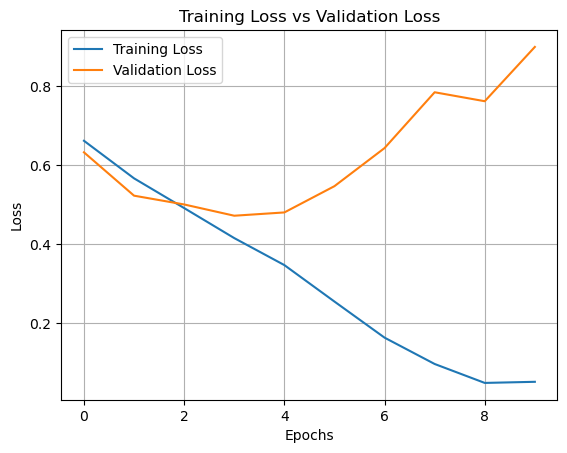

In [12]:
df_loss = pd.DataFrame({
    "Training Loss": train_loss_history,
    "Validation Loss": val_loss_history
})

plt.plot(df_loss["Training Loss"], label="Training Loss")
plt.plot(df_loss["Validation Loss"], label="Validation Loss")

plt.title("Training Loss vs Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.grid(True)
plt.legend()
plt.show()

---
## <u>Load Best Checkpoint</u>

In [13]:
model.load_state_dict(torch.load("best_cat_dog_model.pt", weights_only=True))

<All keys matched successfully>

---
## <u>Evaluate — Training Set</u>

**Why no `argmax` here** -- `argmax` only makes sense when comparing several output neurons within a row (multiclass). This model has exactly 1 output neuron, so there's nothing to compare it *against* within the row -- the decision is threshold-based instead:
- `torch.sigmoid(y_train_pred)` -- turns each raw logit into a probability between 0 and 1 (the same sigmoid `BCEWithLogitsLoss` already applies internally during training, done manually here since the actual probability value is needed for evaluation).
- `(probabilities >= 0.5).float()` -- thresholds each probability into a hard `0`/`1` prediction.

**Why concatenation is unavoidable, not optional** -- predictions/labels exist scattered across one small tensor per batch (~180+ separate tensors by the end of the loop). `accuracy_score` and friends need **one single array covering every sample** to compute a single score. `torch.cat` glues every batch's tensor end-to-end into one `(n,1)` tensor -- there's no version of "one accuracy score across the whole set" that skips this gluing step.

**`.cpu().numpy()`** -- all tensors here live on `device` (MPS). `.numpy()` only works on CPU-resident tensors, so `.cpu()` moves the tensor back to regular system memory first, then `.numpy()` converts it to the array format sklearn's metrics expect.

In [14]:
model.eval()

all_train_preds = []
all_train_labels = []

with torch.no_grad():
    for images, labels in train_loader:

        images, labels = images.to(device), labels.to(device)
        labels = labels.float().unsqueeze(1)

        y_train_pred = model(images)                    # raw logits, shape (batch_size, 1)
        probabilities = torch.sigmoid(y_train_pred)      # turn raw logits into probabilities
        pred_class = (probabilities >= 0.5).float()      # turn probabilities into 0/1 predicted classes

        all_train_preds.append(pred_class)
        all_train_labels.append(labels)

# concatenation -- glue every batch's small tensor into one tensor covering the full training set
all_train_preds = torch.cat(all_train_preds)
all_train_labels = torch.cat(all_train_labels)

# .cpu() moves the tensor off the GPU (numpy can only read from CPU memory), then .numpy() converts it
print("Accuracy Score : ", accuracy_score(all_train_labels.cpu().numpy(), all_train_preds.cpu().numpy()))
print("Precision Score : ", precision_score(all_train_labels.cpu().numpy(), all_train_preds.cpu().numpy()))
print("Recall Score : ", recall_score(all_train_labels.cpu().numpy(), all_train_preds.cpu().numpy()))
print("F1 Score : ", f1_score(all_train_labels.cpu().numpy(), all_train_preds.cpu().numpy()))

Accuracy Score :  0.8688483637272046
Precision Score :  0.8803088803088803
Recall Score :  0.8539325842696629
F1 Score :  0.8669201520912547


---
## <u>Evaluate — Test Set</u>

Same process as the training-set evaluation above, run on `test_loader` instead. `model.eval()` is called again explicitly here rather than relying on the previous cell having already set it -- keeps this cell correct even if run independently.

In [15]:
model.eval()

all_test_preds = []
all_test_labels = []

with torch.no_grad():
    for images, labels in test_loader:

        images, labels = images.to(device), labels.to(device)
        labels = labels.float().unsqueeze(1)

        y_test_pred = model(images)
        probabilities = torch.sigmoid(y_test_pred)
        pred_classes = (probabilities >= 0.5).float()

        all_test_preds.append(pred_classes)
        all_test_labels.append(labels)

all_test_preds = torch.cat(all_test_preds)
all_test_labels = torch.cat(all_test_labels)

print("Accuracy Score : ", accuracy_score(all_test_labels.cpu().numpy(), all_test_preds.cpu().numpy()))
print("Precision Score : ", precision_score(all_test_labels.cpu().numpy(), all_test_preds.cpu().numpy()))
print("Recall Score : ", recall_score(all_test_labels.cpu().numpy(), all_test_preds.cpu().numpy()))
print("F1 Score : ", f1_score(all_test_labels.cpu().numpy(), all_test_preds.cpu().numpy()))

Accuracy Score :  0.7760751359367276
Precision Score :  0.795142555438226
Recall Score :  0.7440711462450593
F1 Score :  0.7687595712098009
